# UPF Literature — Author Co-authorship Network

Builds and analyses a co-authorship network from the edge list produced by
`upf_bibliometrics.py`.  
**Pre-requisite:** run `python upf_bibliometrics.py` (or `--dry-run` for a
quick test) so that `output/coauthorship_edges.csv` exists.

**Install once** (if not already present):
```bash
pip install networkx
```

In [1]:
import collections
import math
import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import networkx as nx
import pandas as pd
import plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')

# ── Paths (relative to notebook location) ─────────────────────────────────────
EDGES_CSV        = os.path.join('..', 'output', 'coauthorship_edges.csv')
AUTHORS_CSV      = os.path.join('..', 'output', 'papers_by_author.csv')
INSTITUTIONS_CSV = os.path.join('..', 'output', 'papers_by_institution.csv')
OUTPUT_DIR       = os.path.join('..', 'output')

# ── Tunable parameters ─────────────────────────────────────────────────────────
MIN_PAPERS      = 3    # keep only authors with >= this many papers in the corpus
MIN_EDGE_WEIGHT = 2    # keep only co-authorship pairs that share >= this many papers
TOP_N_LABELS    = 30   # label the top-N highest-degree nodes in the graph plot
TOP_N_RANKING   = 25   # entries shown in the institution / author ranking charts
LAYOUT_SEED     = 42

print('NetworkX version:', nx.__version__)
print('Plotly version  :', plotly.__version__)

NetworkX version: 3.6.1
Plotly version  : 6.7.0


## 1. Load data

In [2]:
edges_df        = pd.read_csv(EDGES_CSV)
authors_df      = pd.read_csv(AUTHORS_CSV)
institutions_df = pd.read_csv(INSTITUTIONS_CSV)

# Drop the "no institution" catch-all row
institutions_df = institutions_df[
    institutions_df['institution'].notna() & (institutions_df['institution'] != '')
].copy()

print(f'Edge rows         : {len(edges_df):,}')
print(f'Author rows       : {len(authors_df):,}')
print(f'Institution rows  : {len(institutions_df):,}')
edges_df.head(3)

Edge rows         : 130,609
Author rows       : 20,515
Institution rows  : 4,381


,author1_id,author1_name,author1_institution,author1_country,author2_id,author2_name,author2_institution,author2_country,shared_papers
0,https://openalex.org/A5059937532,Renata Bertazzi Levy,Universidade de São Paulo,BR,https://openalex.org/A5044920661,Maria Laura da Costa Louzada,Universidade de São Paulo,BR,65
1,https://openalex.org/A5042007312,Carlos Augusto Monteiro,Universidade de São Paulo,BR,https://openalex.org/A5059937532,Renata Bertazzi Levy,Universidade de São Paulo,BR,63
2,https://openalex.org/A5059937532,Renata Bertazzi Levy,Universidade de São Paulo,BR,https://openalex.org/A5071183177,Fernanda Rauber,Universidade de São Paulo,BR,62


## 2. Build the full graph, then filter

We keep only nodes (authors) that appear in at least `MIN_PAPERS` papers **and**
edges (co-authorship pairs) with at least `MIN_EDGE_WEIGHT` shared papers.
This removes noise from one-off collaborations and focuses the network on
the productive core of the field.

In [3]:
# Node attribute lookup: author_id → {name, institution, country, papers}
# groupby+first handles any duplicate author_id rows (e.g. authors with no
# OpenAlex ID whose fallback key collides across works)
node_attrs = (
    authors_df
    .groupby('author_id', as_index=True)
    .first()[['author_name', 'institution', 'country', 'papers']]
    .to_dict(orient='index')
)

# Productive-author set
core_authors = {
    aid for aid, attr in node_attrs.items()
    if attr['papers'] >= MIN_PAPERS
}
print(f'Authors with >= {MIN_PAPERS} papers : {len(core_authors):,}')

# Build graph
G = nx.Graph()

for _, row in edges_df.iterrows():
    a1, a2, w = row['author1_id'], row['author2_id'], row['shared_papers']
    if a1 not in core_authors or a2 not in core_authors:
        continue
    if w < MIN_EDGE_WEIGHT:
        continue
    if G.has_edge(a1, a2):
        G[a1][a2]['weight'] += w
    else:
        G.add_edge(a1, a2, weight=w)

# Attach node attributes
for node in G.nodes():
    attrs = node_attrs.get(node, {})
    G.nodes[node]['name']        = attrs.get('author_name', node)
    G.nodes[node]['institution'] = attrs.get('institution', '')
    G.nodes[node]['country']     = attrs.get('country', '')
    G.nodes[node]['papers']      = attrs.get('papers', 0)

# Focus on the largest connected component
lcc_nodes = max(nx.connected_components(G), key=len)
G_lcc     = G.subgraph(lcc_nodes).copy()

print(f'Full graph        : {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')
print(f'Largest component : {G_lcc.number_of_nodes():,} nodes, {G_lcc.number_of_edges():,} edges')


Authors with >= 3 papers : 2,356


Full graph        : 2,184 nodes, 10,789 edges
Largest component : 1,380 nodes, 8,921 edges


## 3. Global network statistics

In [4]:
n = G_lcc.number_of_nodes()
m = G_lcc.number_of_edges()
density   = nx.density(G_lcc)
avg_deg   = 2 * m / n if n else 0
avg_clust = nx.average_clustering(G_lcc, weight='weight')
diameter  = nx.diameter(G_lcc) if n < 5_000 else 'skipped (graph too large)'
avg_path  = nx.average_shortest_path_length(G_lcc) if n < 5_000 else 'skipped'
components_full = nx.number_connected_components(G)

print('── Network statistics (largest component) ──────────────')
print(f'  Nodes                 : {n:,}')
print(f'  Edges                 : {m:,}')
print(f'  Density               : {density:.4f}')
print(f'  Average degree        : {avg_deg:.2f}')
print(f'  Average clustering    : {avg_clust:.4f}')
print(f'  Diameter              : {diameter}')
print(f'  Avg shortest path     : {avg_path}')
print(f'  Components (full graph): {components_full:,}')

── Network statistics (largest component) ──────────────
  Nodes                 : 1,380
  Edges                 : 8,921
  Density               : 0.0094
  Average degree        : 12.93
  Average clustering    : 0.0397
  Diameter              : 13
  Avg shortest path     : 4.446804552763502
  Components (full graph): 172


## 4. Centrality measures

In [5]:
degree_cent     = nx.degree_centrality(G_lcc)
betweenness     = nx.betweenness_centrality(G_lcc, weight='weight', normalized=True)
pagerank        = nx.pagerank(G_lcc, weight='weight')
clustering      = nx.clustering(G_lcc, weight='weight')

centrality_df = pd.DataFrame({
    'author_id'   : list(G_lcc.nodes()),
    'name'        : [G_lcc.nodes[n]['name']        for n in G_lcc.nodes()],
    'institution' : [G_lcc.nodes[n]['institution'] for n in G_lcc.nodes()],
    'country'     : [G_lcc.nodes[n]['country']     for n in G_lcc.nodes()],
    'papers'      : [G_lcc.nodes[n]['papers']      for n in G_lcc.nodes()],
    'degree'      : [G_lcc.degree(n)               for n in G_lcc.nodes()],
    'degree_centrality'  : [degree_cent[n]   for n in G_lcc.nodes()],
    'betweenness'        : [betweenness[n]   for n in G_lcc.nodes()],
    'pagerank'           : [pagerank[n]      for n in G_lcc.nodes()],
    'clustering'         : [clustering[n]   for n in G_lcc.nodes()],
})

centrality_df.sort_values('betweenness', ascending=False, inplace=True)
centrality_df.reset_index(drop=True, inplace=True)

# Save
out_path = os.path.join(OUTPUT_DIR, 'author_centrality.csv')
centrality_df.to_csv(out_path, index=False)
print(f'Saved → {out_path}')

print('\nTop 15 by betweenness centrality (bridges / gatekeepers):')
centrality_df[['name', 'institution', 'country', 'papers', 'degree', 'betweenness', 'pagerank']].head(15)

Saved → ../output/author_centrality.csv

Top 15 by betweenness centrality (bridges / gatekeepers):


,name,institution,country,papers,degree,betweenness,pagerank
0,Neha Khandpur,Universidade de São Paulo,BR,96,116,0.142175,0.007424
1,Carlos Augusto Monteiro,Universidade de São Paulo,BR,156,139,0.129257,0.010008
2,Renata Bertazzi Levy,Universidade de São Paulo,BR,143,165,0.107005,0.010824
3,Camila Aparecida Borges,Universidade de São Paulo,BR,15,14,0.101152,0.000678
4,Fernanda Rauber,Universidade de São Paulo,BR,93,138,0.098458,0.007219
5,Eurídice Martínez Steele,Universidade de São Paulo,BR,133,120,0.096528,0.008602
6,Fernanda Helena Marrocos Leite,Universidade de São Paulo,BR,17,38,0.094776,0.001636
7,Daniela Silva Canella,Universidade de São Paulo,BR,55,46,0.080648,0.003363
8,Nassib Bezerra Bueno,Universidade Federal de Alagoas,BR,29,31,0.068789,0.002830
9,Mengxi Du,Tufts University,US,39,62,0.062690,0.003297


In [6]:
print('Top 15 by degree (most direct collaborators):')
centrality_df.sort_values('degree', ascending=False).head(15)[
    ['name', 'institution', 'country', 'papers', 'degree', 'betweenness']
]

Top 15 by degree (most direct collaborators):


,name,institution,country,papers,degree,betweenness
2,Renata Bertazzi Levy,Universidade de São Paulo,BR,143,165,0.107005
1,Carlos Augusto Monteiro,Universidade de São Paulo,BR,156,139,0.129257
4,Fernanda Rauber,Universidade de São Paulo,BR,93,138,0.098458
5,Eurídice Martínez Steele,Universidade de São Paulo,BR,133,120,0.096528
0,Neha Khandpur,Universidade de São Paulo,BR,96,116,0.142175
16,Christopher Millett,Universidade de São Paulo,BR,45,115,0.043840
40,Mathilde Touvier,Sorbonne Paris Cité,FR,71,105,0.022435
29,Bernard Srour,Equipe de Recherche en Epidémiologie Nutrition...,FR,61,103,0.029632
50,Inge Huybrechts,Centre international de recherche sur le cancer,FR,33,86,0.018655
91,Eszter P. Vamos,Imperial College London,GB,35,81,0.008897


## 5. Top-N Rankings — Institutions and Authors

Interactive bar charts. Hover over any bar for full details.  
Change `TOP_N_RANKING` in the parameters cell (cell 1) to show more or fewer entries.

In [7]:
# ── Top-N Institutions ────────────────────────────────────────────────────────
inst_by_papers = (
    institutions_df.nlargest(TOP_N_RANKING, 'papers')
    .assign(label=lambda df: df['institution'].str[:55])
    .sort_values('papers')          # ascending → largest at top in horizontal bar
)
inst_by_cites = (
    institutions_df.nlargest(TOP_N_RANKING, 'citations')
    .assign(label=lambda df: df['institution'].str[:55])
    .sort_values('citations')
)

fig_inst = go.Figure()

fig_inst.add_trace(go.Bar(
    x=inst_by_papers['papers'],
    y=inst_by_papers['label'],
    orientation='h',
    name='Papers',
    visible=True,
    customdata=inst_by_papers[['institution', 'country', 'citations']].values,
    hovertemplate=(
        '<b>%{customdata[0]}</b><br>'
        'Country: %{customdata[1]}<br>'
        'Papers: %{x:,}<br>'
        'Citations: %{customdata[2]:,}<extra></extra>'
    ),
    marker_color='steelblue',
))

fig_inst.add_trace(go.Bar(
    x=inst_by_cites['citations'],
    y=inst_by_cites['label'],
    orientation='h',
    name='Citations',
    visible=False,
    customdata=inst_by_cites[['institution', 'country', 'papers']].values,
    hovertemplate=(
        '<b>%{customdata[0]}</b><br>'
        'Country: %{customdata[1]}<br>'
        'Citations: %{x:,}<br>'
        'Papers: %{customdata[2]:,}<extra></extra>'
    ),
    marker_color='coral',
))

fig_inst.update_layout(
    title=f'Top {TOP_N_RANKING} Institutions by Paper Count',
    height=700,
    xaxis_title='Papers',
    yaxis_title='',
    showlegend=False,
    margin=dict(l=10, r=20, t=60, b=40),
    updatemenus=[dict(
        type='buttons',
        direction='right',
        x=0.0, xanchor='left',
        y=1.08, yanchor='top',
        buttons=[
            dict(
                label='By Papers',
                method='update',
                args=[{'visible': [True, False]},
                      {'title': f'Top {TOP_N_RANKING} Institutions by Paper Count',
                       'xaxis.title.text': 'Papers'}],
            ),
            dict(
                label='By Citations',
                method='update',
                args=[{'visible': [False, True]},
                      {'title': f'Top {TOP_N_RANKING} Institutions by Citation Count',
                       'xaxis.title.text': 'Citations'}],
            ),
        ],
    )],
)
fig_inst.show()

In [8]:
# ── Top-N Authors ─────────────────────────────────────────────────────────────
authors_clean = authors_df[
    authors_df['author_name'].notna() & (authors_df['author_name'] != '')
].copy()

auth_by_papers = (
    authors_clean.nlargest(TOP_N_RANKING, 'papers')
    .sort_values('papers')
)
auth_by_cites = (
    authors_clean.nlargest(TOP_N_RANKING, 'citations')
    .sort_values('citations')
)

fig_auth = go.Figure()

fig_auth.add_trace(go.Bar(
    x=auth_by_papers['papers'],
    y=auth_by_papers['author_name'],
    orientation='h',
    name='Papers',
    visible=True,
    customdata=auth_by_papers[['institution', 'country', 'citations']].values,
    hovertemplate=(
        '<b>%{y}</b><br>'
        'Institution: %{customdata[0]}<br>'
        'Country: %{customdata[1]}<br>'
        'Papers: %{x:,}<br>'
        'Citations: %{customdata[2]:,}<extra></extra>'
    ),
    marker_color='steelblue',
))

fig_auth.add_trace(go.Bar(
    x=auth_by_cites['citations'],
    y=auth_by_cites['author_name'],
    orientation='h',
    name='Citations',
    visible=False,
    customdata=auth_by_cites[['institution', 'country', 'papers']].values,
    hovertemplate=(
        '<b>%{y}</b><br>'
        'Institution: %{customdata[0]}<br>'
        'Country: %{customdata[1]}<br>'
        'Citations: %{x:,}<br>'
        'Papers: %{customdata[2]:,}<extra></extra>'
    ),
    marker_color='coral',
))

fig_auth.update_layout(
    title=f'Top {TOP_N_RANKING} Authors by Paper Count',
    height=700,
    xaxis_title='Papers',
    yaxis_title='',
    showlegend=False,
    margin=dict(l=10, r=20, t=60, b=40),
    updatemenus=[dict(
        type='buttons',
        direction='right',
        x=0.0, xanchor='left',
        y=1.08, yanchor='top',
        buttons=[
            dict(
                label='By Papers',
                method='update',
                args=[{'visible': [True, False]},
                      {'title': f'Top {TOP_N_RANKING} Authors by Paper Count',
                       'xaxis.title.text': 'Papers'}],
            ),
            dict(
                label='By Citations',
                method='update',
                args=[{'visible': [False, True]},
                      {'title': f'Top {TOP_N_RANKING} Authors by Citation Count',
                       'xaxis.title.text': 'Citations'}],
            ),
        ],
    )],
)
fig_auth.show()

## 5. Community detection

Uses the Louvain algorithm (built into NetworkX ≥ 2.7) to partition the
network into research communities.

In [9]:
communities = nx.community.louvain_communities(G_lcc, weight='weight', seed=LAYOUT_SEED)
communities = sorted(communities, key=len, reverse=True)

print(f'Number of communities detected: {len(communities)}')
print(f'Sizes of top-10 communities   : {[len(c) for c in communities[:10]]}')

# Assign community labels to nodes
node_community = {}
for idx, community in enumerate(communities):
    for node in community:
        node_community[node] = idx

nx.set_node_attributes(G_lcc, node_community, 'community')

# Add to centrality table
centrality_df['community'] = centrality_df['author_id'].map(node_community)

# Per-community summary
comm_summary = (
    centrality_df
    .groupby('community')
    .agg(
        size=('name', 'count'),
        total_papers=('papers', 'sum'),
        top_country=('country', lambda x: x.value_counts().index[0] if len(x) else ''),
        top_institution=('institution', lambda x: x.value_counts().index[0] if len(x) else ''),
    )
    .sort_values('size', ascending=False)
    .head(10)
)
print('\nTop-10 communities:')
comm_summary

Number of communities detected: 27
Sizes of top-10 communities   : [197, 151, 111, 101, 90, 77, 66, 66, 64, 59]

Top-10 communities:


,size,total_papers,top_country,top_institution
community,,,,
0,197,2176,BR,Universidade de São Paulo
1,151,1055,BR,Universidade Federal de Minas Gerais
2,111,774,AU,Deakin University
3,101,736,GB,Centre international de recherche sur le cancer
4,90,576,ES,Instituto de Salud Carlos III
5,77,669,US,Harvard University
6,66,432,US,Johns Hopkins University
7,66,397,BR,Universidade Federal do Rio de Janeiro
8,64,388,US,National Institute of Diabetes and Digestive a...


## 6. Visualisations

### 6a. Degree distribution

In [10]:
degrees = [d for _, d in G_lcc.degree()]
freq    = collections.Counter(degrees)
deg_df  = pd.DataFrame({'degree': list(freq.keys()), 'count': list(freq.values())}).sort_values('degree')

fig_deg = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Degree Distribution (linear)', 'Degree Distribution (log–log)'],
)

fig_deg.add_trace(
    go.Histogram(x=degrees, nbinsx=40, name='Count', marker_color='steelblue'),
    row=1, col=1,
)
fig_deg.add_trace(
    go.Scatter(
        x=deg_df['degree'], y=deg_df['count'],
        mode='markers',
        marker=dict(size=5, color='steelblue', opacity=0.7),
        hovertemplate='Degree: %{x}<br>Count: %{y}<extra></extra>',
        name='Count',
    ),
    row=1, col=2,
)

fig_deg.update_xaxes(title_text='Degree', row=1, col=1)
fig_deg.update_yaxes(title_text='Count', row=1, col=1)
fig_deg.update_xaxes(type='log', title_text='Degree (log)', row=1, col=2)
fig_deg.update_yaxes(type='log', title_text='Count (log)', row=1, col=2)
fig_deg.update_layout(
    height=420,
    showlegend=False,
    title_text=(
        f'Degree Distribution  |  '
        f'Mean: {sum(degrees)/len(degrees):.2f}  |  Max: {max(degrees)}'
    ),
)
fig_deg.show()
print(f'Mean degree: {sum(degrees)/len(degrees):.2f}  Max: {max(degrees)}')

Mean degree: 12.93  Max: 165


### 6b. Co-authorship network (largest component, coloured by community)

Plotting top-500 nodes by degree (graph has 1,380 total)


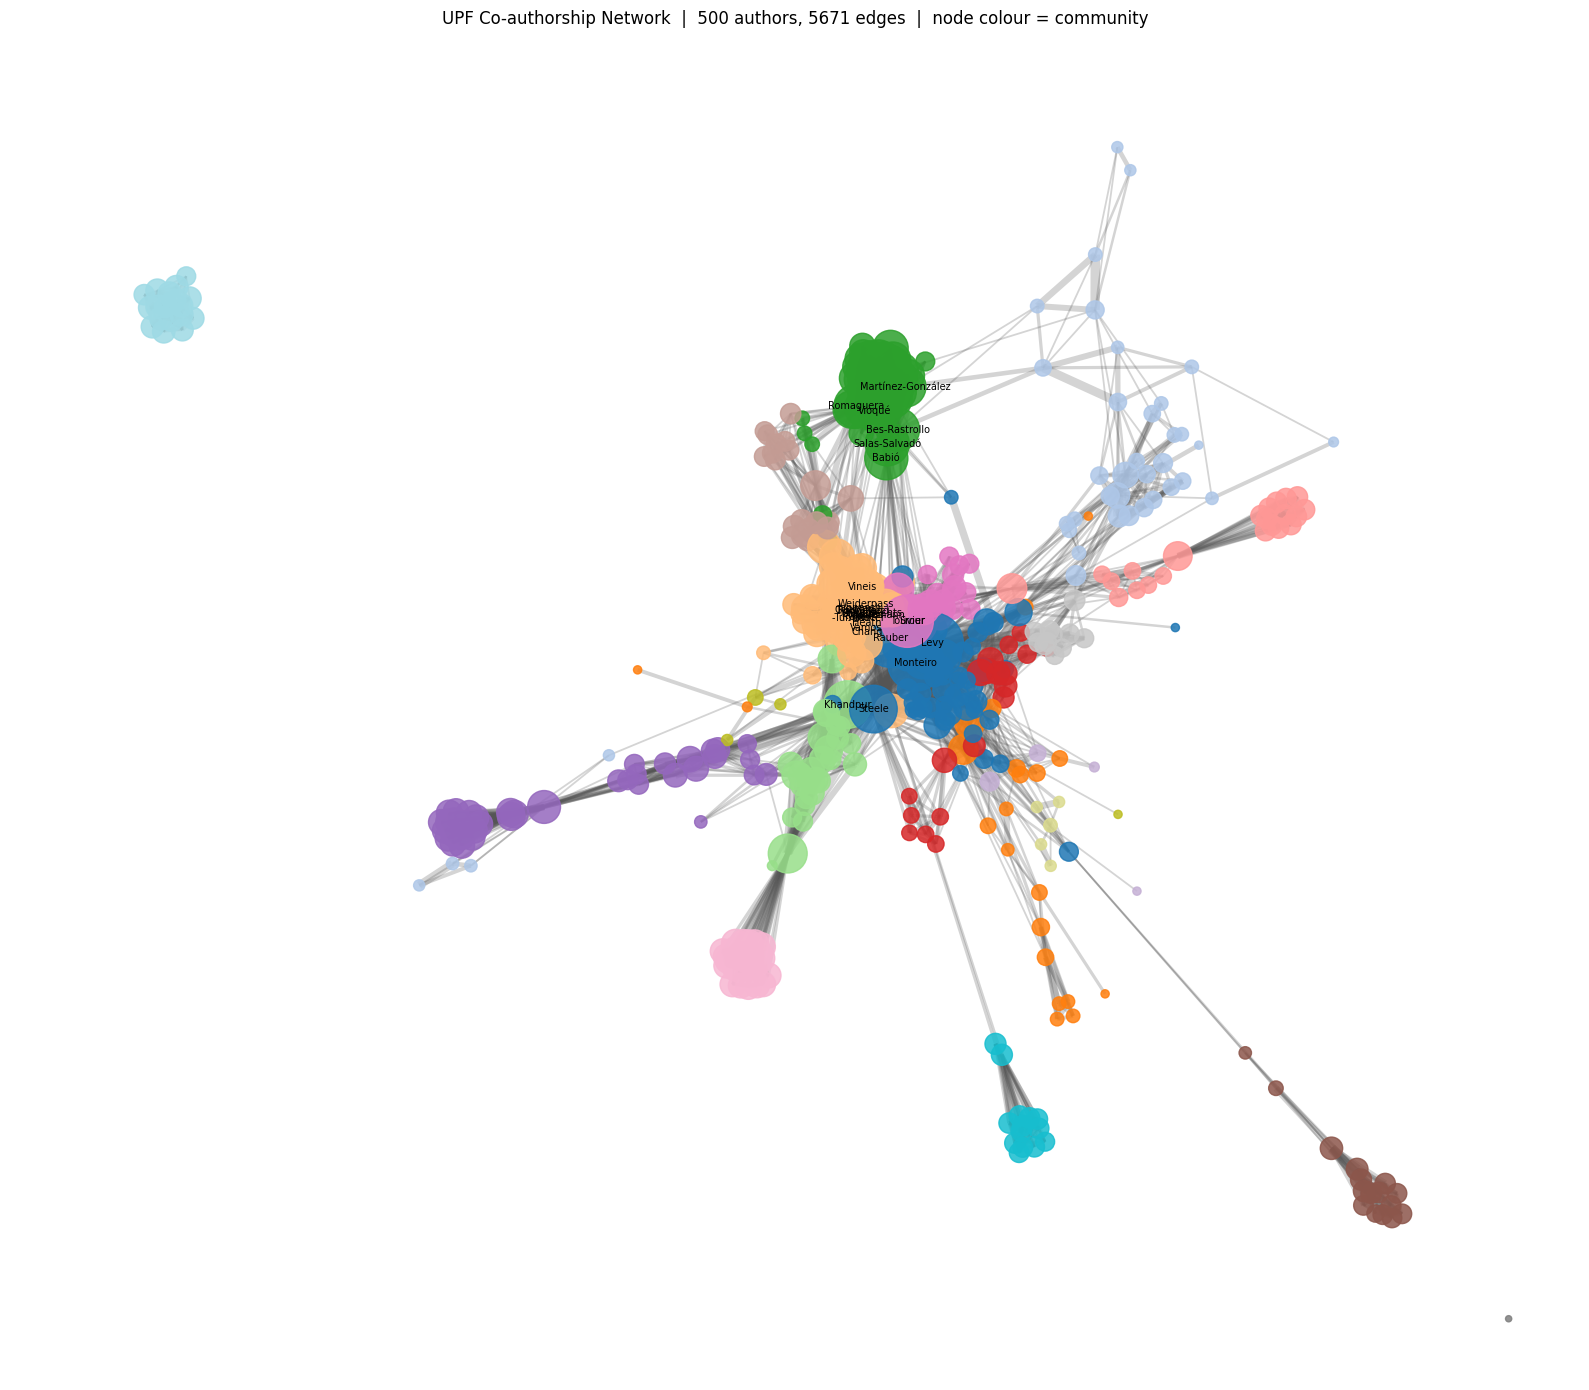

In [11]:
# For legibility, cap the plotted graph at 500 nodes (highest-degree subset)
PLOT_CAP = 500
if G_lcc.number_of_nodes() > PLOT_CAP:
    top_nodes = sorted(G_lcc.nodes(), key=lambda n: G_lcc.degree(n), reverse=True)[:PLOT_CAP]
    G_plot = G_lcc.subgraph(top_nodes).copy()
    print(f'Plotting top-{PLOT_CAP} nodes by degree (graph has {G_lcc.number_of_nodes():,} total)')
else:
    G_plot = G_lcc

pos = nx.spring_layout(G_plot, weight='weight', seed=LAYOUT_SEED, k=0.8)

n_communities = max(node_community.values()) + 1 if node_community else 1
cmap = cm.get_cmap('tab20', min(n_communities, 20))

node_colors = [
    cmap(G_plot.nodes[n].get('community', 0) % 20)
    for n in G_plot.nodes()
]
node_sizes = [
    20 + 15 * G_plot.degree(n)
    for n in G_plot.nodes()
]
edge_widths = [
    0.3 + 0.5 * G_plot[u][v].get('weight', 1)
    for u, v in G_plot.edges()
]

fig, ax = plt.subplots(figsize=(16, 14))

nx.draw_networkx_edges(
    G_plot, pos, ax=ax,
    width=edge_widths, alpha=0.25, edge_color='#555555'
)
nx.draw_networkx_nodes(
    G_plot, pos, ax=ax,
    node_color=node_colors, node_size=node_sizes, alpha=0.85
)

# Label top-N nodes
top_label_nodes = sorted(G_plot.nodes(), key=lambda n: G_plot.degree(n), reverse=True)[:TOP_N_LABELS]
labels = {n: G_plot.nodes[n].get('name', n).split()[-1] for n in top_label_nodes}  # last name only
nx.draw_networkx_labels(
    G_plot, pos, labels=labels, ax=ax,
    font_size=7, font_color='black'
)

ax.set_title(
    f'UPF Co-authorship Network  |  '
    f'{G_plot.number_of_nodes()} authors, {G_plot.number_of_edges()} edges  |  '
    f'node colour = community',
    fontsize=12
)
ax.axis('off')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'author_network.png'), dpi=150)
plt.show()

### 6c. Betweenness vs degree scatter — identifying bridges

In [12]:
# Treat community as a categorical label so plotly uses discrete colours
plot_df = centrality_df.copy()
plot_df['community_label'] = 'Community ' + plot_df['community'].fillna(-1).astype(int).astype(str)

fig_scatter = px.scatter(
    plot_df,
    x='degree',
    y='betweenness',
    size='papers',
    color='community_label',
    hover_name='name',
    hover_data={
        'institution': True,
        'country': True,
        'papers': True,
        'degree': True,
        'betweenness': ':.4f',
        'pagerank': ':.4f',
        'community_label': False,
    },
    title='Degree vs Betweenness Centrality  |  point size ∝ papers  |  colour = community',
    labels={
        'degree': 'Degree (number of co-authors)',
        'betweenness': 'Betweenness centrality',
        'community_label': 'Community',
    },
    color_discrete_sequence=px.colors.qualitative.Alphabet,
    size_max=30,
    height=650,
)
fig_scatter.update_traces(marker_opacity=0.7)
fig_scatter.update_layout(legend_title_text='Community')
fig_scatter.show()

### 6d. Country-level collaboration heatmap

Counts co-authored papers between pairs of countries.

## 7. Save enriched centrality table

In [13]:
out_path = os.path.join(OUTPUT_DIR, 'author_centrality.csv')
cols = ['author_id', 'name', 'institution', 'country', 'community',
        'papers', 'degree', 'degree_centrality', 'betweenness', 'pagerank', 'clustering']
centrality_df[cols].sort_values('betweenness', ascending=False).to_csv(out_path, index=False)
print(f'Saved enriched centrality table → {out_path}')
centrality_df[cols].head(10)

Saved enriched centrality table → ../output/author_centrality.csv


,author_id,name,institution,country,community,papers,degree,degree_centrality,betweenness,pagerank,clustering
0,https://openalex.org/A5039598820,Neha Khandpur,Universidade de São Paulo,BR,5,96,116,0.084119,0.142175,0.007424,0.009748
1,https://openalex.org/A5042007312,Carlos Augusto Monteiro,Universidade de São Paulo,BR,0,156,139,0.100798,0.129257,0.010008,0.012995
2,https://openalex.org/A5059937532,Renata Bertazzi Levy,Universidade de São Paulo,BR,0,143,165,0.119652,0.107005,0.010824,0.012151
3,https://openalex.org/A5009644208,Camila Aparecida Borges,Universidade de São Paulo,BR,0,15,14,0.010152,0.101152,0.000678,0.017414
4,https://openalex.org/A5071183177,Fernanda Rauber,Universidade de São Paulo,BR,0,93,138,0.100073,0.098458,0.007219,0.015323
5,https://openalex.org/A5064834293,Eurídice Martínez Steele,Universidade de São Paulo,BR,0,133,120,0.087020,0.096528,0.008602,0.009033
6,https://openalex.org/A5083070262,Fernanda Helena Marrocos Leite,Universidade de São Paulo,BR,0,17,38,0.027556,0.094776,0.001636,0.013123
7,https://openalex.org/A5048645214,Daniela Silva Canella,Universidade de São Paulo,BR,0,55,46,0.033358,0.080648,0.003363,0.010542
8,https://openalex.org/A5046488279,Nassib Bezerra Bueno,Universidade Federal de Alagoas,BR,10,29,31,0.022480,0.068789,0.002830,0.023066
9,https://openalex.org/A5100735336,Mengxi Du,Tufts University,US,5,39,62,0.044960,0.062690,0.003297,0.020307


## 9. Export interactive HTML dashboard

Produces a single self-contained HTML file (`output/upf_dashboard.html`) that
can be uploaded to any web server and opened in a browser — no Python or Jupyter
required.  Plotly.js is loaded from CDN; all interactivity (zoom, pan, hover,
"Papers / Citations" toggle buttons) is preserved.

In [14]:
dashboard_figures = [
    ('Top-N Institutions',                fig_inst),
    ('Top-N Authors',                     fig_auth),
    ('Degree Distribution',               fig_deg),
    ('Degree vs Betweenness Centrality',  fig_scatter),
]

# ── Build HTML ─────────────────────────────────────────────────────────────────
generated_at = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')

header = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>UPF Bibliometrics — Interactive Dashboard</title>
<style>
  body  {{ font-family: Arial, Helvetica, sans-serif; max-width: 1400px;
          margin: 0 auto; padding: 24px; background: #f4f6f9; color: #333; }}
  h1   {{ font-size: 1.6rem; border-bottom: 3px solid #2c7bb6; padding-bottom: 8px; }}
  h2   {{ font-size: 1.1rem; color: #555; margin: 40px 0 6px; }}
  .chart {{ background: #fff; border-radius: 8px; padding: 12px;
            margin-bottom: 32px; box-shadow: 0 1px 5px rgba(0,0,0,.1); }}
  footer {{ color: #999; font-size: .8rem; margin-top: 40px; border-top: 1px solid #ddd; padding-top: 8px; }}
</style>
</head>
<body>
<h1>UPF Bibliometrics — Interactive Dashboard</h1>
<p>Generated: {generated_at} &nbsp;|&nbsp;
   Source: <a href="https://openalex.org" target="_blank">OpenAlex</a></p>
"""

footer = """
<footer>Generated with <a href="https://plotly.com/python/" target="_blank">Plotly</a>
and the UPF bibliometrics pipeline.</footer>
</body></html>"""

parts = [header]
first = True
for section_title, fig in dashboard_figures:
    chart_html = fig.to_html(
        full_html=False,
        include_plotlyjs='cdn' if first else False,
        config={'displayModeBar': True, 'scrollZoom': False},
    )
    parts.append(f'<h2>{section_title}</h2>\n<div class="chart">\n{chart_html}\n</div>')
    first = False

parts.append(footer)

html_path = os.path.join(OUTPUT_DIR, 'upf_dashboard.html')
with open(html_path, 'w', encoding='utf-8') as fh:
    fh.write('\n'.join(parts))

size_kb = os.path.getsize(html_path) / 1024
print(f'Saved → {html_path}  ({size_kb:.0f} KB)')
print('Upload this single file to any web server to share the dashboard.')

Saved → ../output/upf_dashboard.html  (225 KB)
Upload this single file to any web server to share the dashboard.
